In [2]:
import sys
import warnings
import itertools
import calendar
from pylab import rcParams
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
%matplotlib inline
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

In [109]:
data = pd.read_csv('Gas.csv')

In [110]:
data.head()

,Unnamed: 0,x
0,1,1709
1,2,1646
2,3,1794
3,4,1878
4,5,2173


In [111]:
dates = pd.date_range(start = '1/1/1990', periods = len(data), freq='M')
dates

DatetimeIndex(['1990-01-31', '1990-02-28', '1990-03-31', '1990-04-30',
               '1990-05-31', '1990-06-30', '1990-07-31', '1990-08-31',
               '1990-09-30', '1990-10-31',
               ...
               '2028-11-30', '2028-12-31', '2029-01-31', '2029-02-28',
               '2029-03-31', '2029-04-30', '2029-05-31', '2029-06-30',
               '2029-07-31', '2029-08-31'],
              dtype='datetime64[ns]', length=476, freq='M')

In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  476 non-null    int64
 1   x           476 non-null    int64
dtypes: int64(2)
memory usage: 7.6 KB


In [113]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [114]:
data['ds'] = dates

In [115]:
data.rename(columns={'x':'y'}, inplace=True)

In [116]:
data = data[['ds','y']]

In [117]:
data.head()

,ds,y
0,1990-01-31,1709
1,1990-02-28,1646
2,1990-03-31,1794
3,1990-04-30,1878
4,1990-05-31,2173


In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      476 non-null    datetime64[ns]
 1   y       476 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 7.6 KB


In [119]:
data.isnull().sum()

ds    0
y     0
dtype: int64

In [120]:
data.isna().sum()

ds    0
y     0
dtype: int64

In [121]:
data.isin([0]).sum()

ds    0
y     0
dtype: int64

In [122]:
data_x = data.copy() #for ARIMA SARIMA models
data_y = data.copy() # for Prophet

In [17]:
data['Month'] = dates.month
data['Year'] = dates.year
data['Month'] = data['Month'].apply(lambda x: calendar.month_abbr[x])

In [18]:
data.set_index('ds', inplace=True)

In [19]:
data.head()

,y,Month,Year
ds,,,
1990-01-31,1709,Jan,1990
1990-02-28,1646,Feb,1990
1990-03-31,1794,Mar,1990
1990-04-30,1878,Apr,1990
1990-05-31,2173,May,1990


### Exploratory Data Analysis

<Axes: xlabel='ds'>

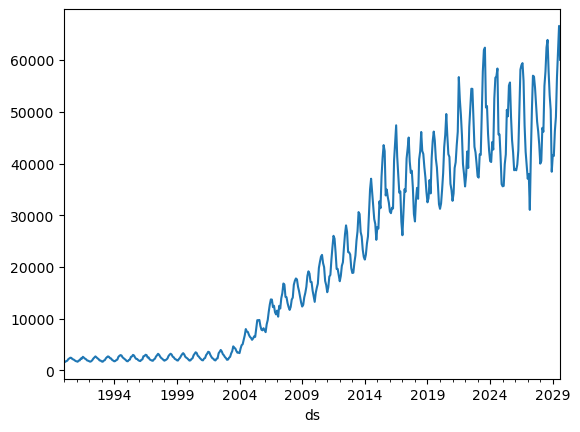

In [20]:
data['y'].plot()

In [21]:
yearly_gas = pd.pivot_table(data, values = 'y', columns='Year',index='Month')
yearly_gas = yearly_gas.reindex(index=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
yearly_gas

Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029
Month,,,,,,,,,,,,,,,,,,,,,
Jan,1709.0,1751.0,1773.0,1730.0,1762.0,1804.0,1868.0,1910.0,1889.0,1962.0,...,31239.0,32791.0,35567.0,37541.0,40459.0,35592.0,38963.0,37059.0,39975.0,41600.0
Feb,1646.0,1688.0,1688.0,1688.0,1815.0,1773.0,1815.0,1868.0,1984.0,1910.0,...,32261.0,34206.0,37696.0,37277.0,40295.0,35677.0,38690.0,37963.0,40478.0,41471.0
Mar,1794.0,1920.0,1783.0,1899.0,2005.0,2015.0,2047.0,2121.0,2110.0,2216.0,...,34951.0,39128.0,42319.0,41778.0,44147.0,39864.0,39792.0,31043.0,46895.0,46287.0
Apr,1878.0,1941.0,1984.0,1994.0,2089.0,2089.0,2142.0,2268.0,2311.0,2437.0,...,38109.0,40249.0,39137.0,41666.0,42697.0,41761.0,42545.0,41712.0,46147.0,49013.0
May,2173.0,2311.0,2290.0,2342.0,2617.0,2627.0,2743.0,2690.0,2785.0,2817.0,...,43168.0,43519.0,47062.0,49616.0,52561.0,50380.0,50145.0,50366.0,55011.0,56624.0
Jun,2321.0,2279.0,2511.0,2553.0,2828.0,2712.0,2775.0,2933.0,3039.0,3123.0,...,45547.0,46137.0,50610.0,57793.0,56572.0,49129.0,58164.0,56977.0,57799.0,61739.0
Jul,2468.0,2638.0,2712.0,2712.0,2965.0,3007.0,3028.0,3218.0,3229.0,3345.0,...,49568.0,56709.0,54457.0,61884.0,56858.0,55066.0,59035.0,56807.0,62450.0,66600.0
Aug,2416.0,2448.0,2522.0,2627.0,2891.0,2880.0,2965.0,3028.0,3070.0,3112.0,...,45387.0,52306.0,54435.0,62400.0,58363.0,55671.0,59408.0,54634.0,63896.0,60054.0
Sep,2184.0,2279.0,2342.0,2363.0,2532.0,2490.0,2501.0,2659.0,2659.0,2659.0,...,41805.0,49397.0,48516.0,50820.0,45627.0,49058.0,55988.0,51367.0,57784.0,NaN


In [22]:
monthly_gas = pd.pivot_table(data, values = 'y', columns='Month',index='Year')
monthly_gas = monthly_gas[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]
monthly_gas

Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,,,,,,,,,,,,
1990,1709.0,1646.0,1794.0,1878.0,2173.0,2321.0,2468.0,2416.0,2184.0,2121.0,1962.0,1825.0
1991,1751.0,1688.0,1920.0,1941.0,2311.0,2279.0,2638.0,2448.0,2279.0,2163.0,1941.0,1878.0
1992,1773.0,1688.0,1783.0,1984.0,2290.0,2511.0,2712.0,2522.0,2342.0,2195.0,1931.0,1910.0
1993,1730.0,1688.0,1899.0,1994.0,2342.0,2553.0,2712.0,2627.0,2363.0,2311.0,2026.0,1910.0
1994,1762.0,1815.0,2005.0,2089.0,2617.0,2828.0,2965.0,2891.0,2532.0,2363.0,2216.0,2026.0
1995,1804.0,1773.0,2015.0,2089.0,2627.0,2712.0,3007.0,2880.0,2490.0,2237.0,2205.0,1984.0
1996,1868.0,1815.0,2047.0,2142.0,2743.0,2775.0,3028.0,2965.0,2501.0,2501.0,2131.0,2015.0
1997,1910.0,1868.0,2121.0,2268.0,2690.0,2933.0,3218.0,3028.0,2659.0,2406.0,2258.0,2057.0
1998,1889.0,1984.0,2110.0,2311.0,2785.0,3039.0,3229.0,3070.0,2659.0,2543.0,2237.0,2142.0


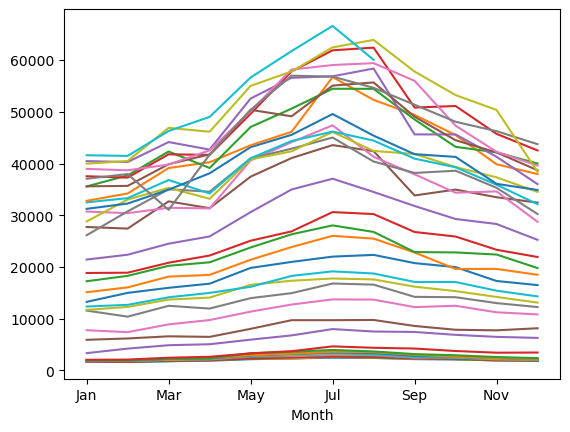

In [23]:
yearly_gas.plot(legend=False)
plt.show();

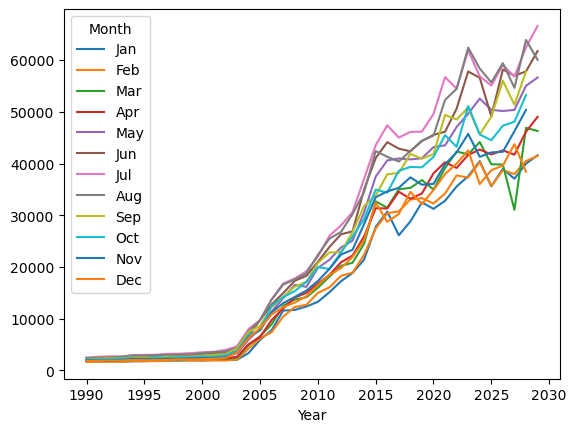

In [24]:
monthly_gas.plot()
plt.show();

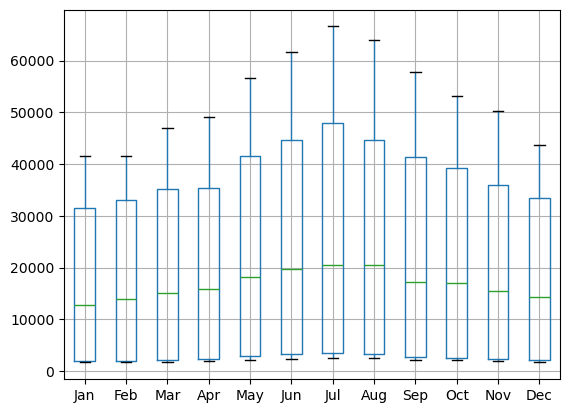

In [25]:
monthly_gas.boxplot()
plt.show();

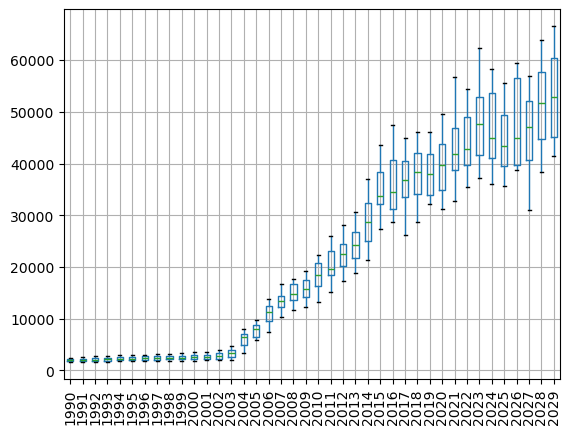

In [26]:
yearly_gas.boxplot()
plt.xticks(rotation=90)
plt.show();

### Stationarity

In [29]:
data_x.head()

,ds,y
0,1990-01-31,1709
1,1990-02-28,1646
2,1990-03-31,1794
3,1990-04-30,1878
4,1990-05-31,2173


In [30]:
data_x.set_index('ds', inplace=True)

In [31]:
dftest = adfuller(data_x)
dftest[0]

0.4206212178228288

In [32]:
dftest[1]

0.9822499353484766

In [33]:
data_xlog = np.log10(data_x)

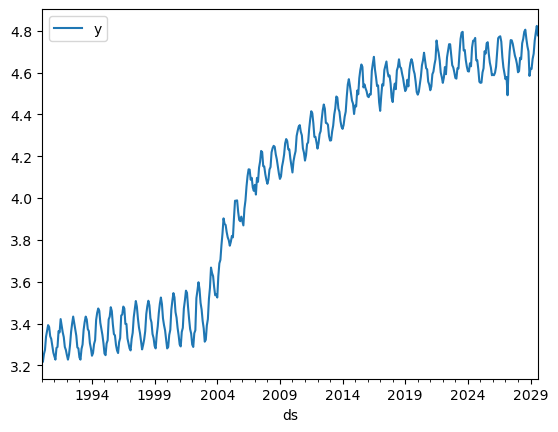

In [34]:
data_xlog.plot()
plt.show();

In [35]:
data_diff = data_xlog.diff().dropna()

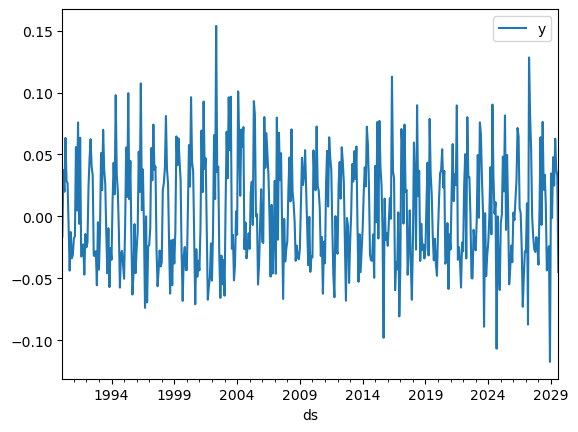

In [36]:
data_diff.plot()
plt.show();

### ACF and PACF Plots

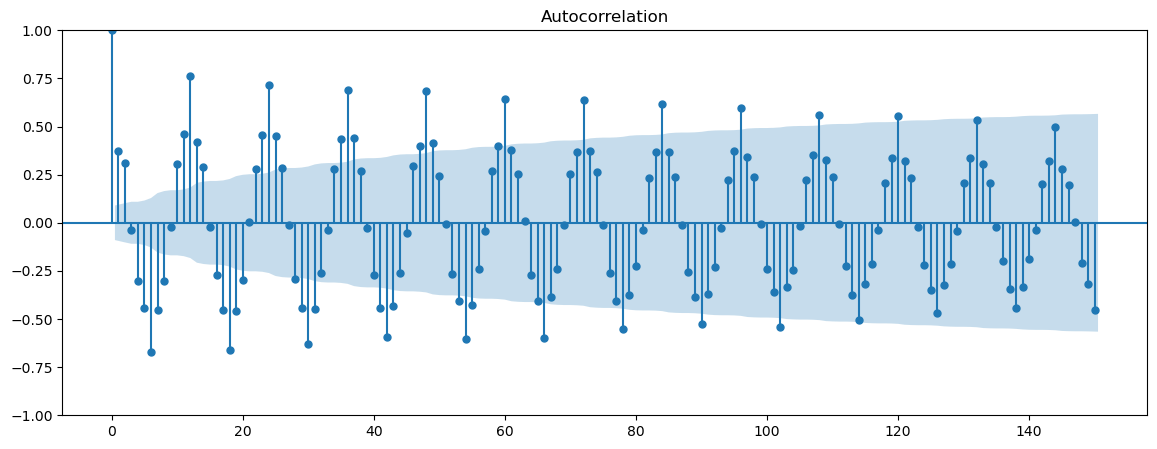

In [37]:
fig, ax = plt.subplots(figsize=(14,5))
plot_acf(data_diff, lags=150, ax=ax)
plt.show();

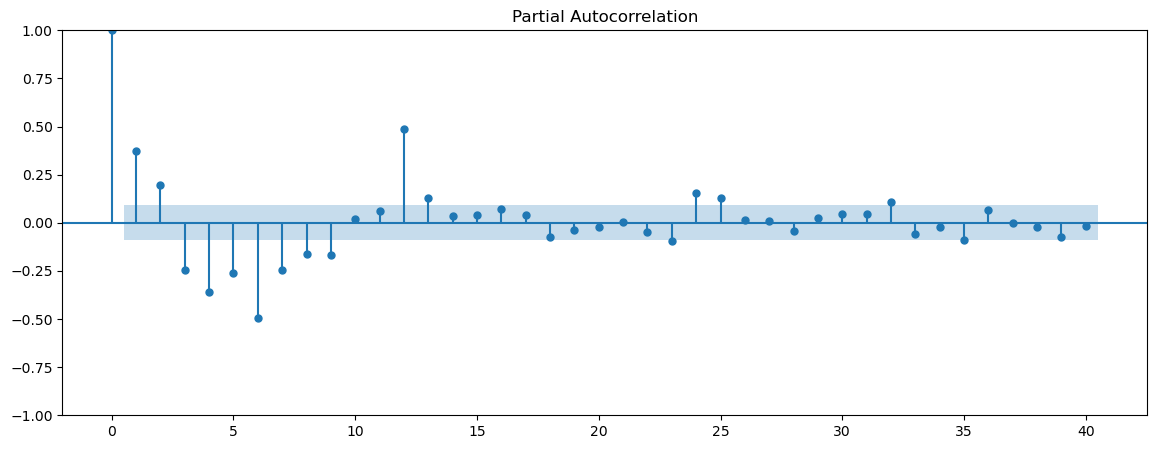

In [38]:
fig, ax = plt.subplots(figsize=(14,5))
plot_pacf(data_diff, lags=40, ax=ax)
plt.show();

### Train Test Split

In [39]:
train = data_diff[0:int(len(data_diff)*0.7)]
test = data_diff[int(len(data_diff)*0.7):]

In [40]:
print(train.shape)
print(test.shape)

(332, 1)
(143, 1)


### Defining the pdq estimation matrices for model building

In [41]:
p = q = range(1,5)
d = range(0,2)
pdq = list(itertools.product(p,d,q))
pdq_sarima = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p,d,q))]

In [42]:
pdq

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 0, 4),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 0, 4),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 0, 4),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 1, 4),
 (4, 0, 1),
 (4, 0, 2),
 (4, 0, 3),
 (4, 0, 4),
 (4, 1, 1),
 (4, 1, 2),
 (4, 1, 3),
 (4, 1, 4)]

In [43]:
pdq_sarima

[(1, 0, 1, 12),
 (1, 0, 2, 12),
 (1, 0, 3, 12),
 (1, 0, 4, 12),
 (1, 1, 1, 12),
 (1, 1, 2, 12),
 (1, 1, 3, 12),
 (1, 1, 4, 12),
 (2, 0, 1, 12),
 (2, 0, 2, 12),
 (2, 0, 3, 12),
 (2, 0, 4, 12),
 (2, 1, 1, 12),
 (2, 1, 2, 12),
 (2, 1, 3, 12),
 (2, 1, 4, 12),
 (3, 0, 1, 12),
 (3, 0, 2, 12),
 (3, 0, 3, 12),
 (3, 0, 4, 12),
 (3, 1, 1, 12),
 (3, 1, 2, 12),
 (3, 1, 3, 12),
 (3, 1, 4, 12),
 (4, 0, 1, 12),
 (4, 0, 2, 12),
 (4, 0, 3, 12),
 (4, 0, 4, 12),
 (4, 1, 1, 12),
 (4, 1, 2, 12),
 (4, 1, 3, 12),
 (4, 1, 4, 12)]

### AUTO ARIMA Model

In [44]:
arima_aic = pd.DataFrame(columns=['param','AIC'])
arima_aic

,param,AIC


In [45]:
for param in pdq:
    ARIMA_model = ARIMA(train, order=param).fit()
    arima_aic = pd.concat([arima_aic,pd.DataFrame({'param':[param],'AIC':[ARIMA_model.aic]})],ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequenc

In [46]:
arima_aic = arima_aic.sort_values(by='AIC')
arima_aic.head()

,param,AIC
27,"(4, 0, 4)",-1496.723664
19,"(3, 0, 4)",-1471.752702
11,"(2, 0, 4)",-1458.887898
26,"(4, 0, 3)",-1452.687063
18,"(3, 0, 3)",-1449.006510


In [47]:
best_results_arima = ARIMA(train, order=(4,0,4)).fit()
print(best_results_arima.summary().tables[0])
print(best_results_arima.summary().tables[1])

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  332
Model:                 ARIMA(4, 0, 4)   Log Likelihood                 758.362
Date:                Thu, 01 May 2025   AIC                          -1496.724
Time:                        15:19:52   BIC                          -1458.672
Sample:                    02-28-1990   HQIC                         -1481.549
                         - 09-30-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0035      0.001      3.671      0.000       0.002       0.005
ar.L1          0.0163      0.017      0.978      0.328      -0.016       0.049
ar.L2          0.9971      0.019     52.964      0.0

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [143]:
pred_dynamic_arima = best_results_arima.get_prediction(start=test.index[0], dynamic=True, full_results=True)
pred95_arima = best_results_arima.get_forecast(steps=len(test), alpha=0.05)
gas_forecasted = pred_dynamic_arima.predicted_mean
testcopy_arima = test.copy()
testcopy_arima['gas_forecasted'] = np.power(10, pred95_arima.predicted_mean.cumsum() + (train['y'].iloc[-1]))

In [144]:
mse_arima = ((test['y'] - testcopy_arima['gas_forecasted'])**2).mean()
rmse_arima = np.sqrt(mse_arima)
rmse_arima

1.7987690451510354

In [50]:
arima_results = pd.DataFrame({'Model':['ARIMA(4,0,4)]'], 'RMSE':[rmse_arima]})
arima_results

,Model,RMSE
0,"ARIMA(4,0,4)]",1.798769


### SARIMA Model

In [51]:
sarima_aic = pd.DataFrame(columns=['param','seasonal','AIC'])
sarima_aic

,param,seasonal,AIC


In [52]:
for param in pdq:
    for seasonal_param in pdq_sarima:
        SARIMA_model = sm.tsa.statespace.SARIMAX(train, order=param, seasonal_order=seasonal_param, enforce_stationarity=False, enforce_invertibility=False).fit(maxiter=1000)
        sarima_aic = pd.concat([sarima_aic, pd.DataFrame({'param':[param],'seasonal':[seasonal_param],'AIC':[SARIMA_model.aic]})], ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequenc

In [53]:
sarima_aic = sarima_aic.sort_values(by='AIC')
sarima_aic

,param,seasonal,AIC
0,"(1, 0, 1)","(1, 0, 1, 12)",-1550.460175
256,"(2, 0, 1)","(1, 0, 1, 12)",-1548.119660
864,"(4, 0, 4)","(1, 0, 1, 12)",-1546.745911
576,"(3, 0, 3)","(1, 0, 1, 12)",-1545.202289
512,"(3, 0, 1)","(1, 0, 1, 12)",-1541.388418
...,...,...,...
1023,"(4, 1, 4)","(4, 1, 4, 12)",-1257.391850
511,"(2, 1, 4)","(4, 1, 4, 12)",-1255.744028
767,"(3, 1, 4)","(4, 1, 4, 12)",-1254.125826
263,"(2, 0, 1)","(1, 1, 4, 12)",-1170.237782


In [54]:
best_results_sarima = sm.tsa.statespace.SARIMAX(train, order=(1,0,1), seasonal_order = (1,0,1,12), enforce_stationarity=True).fit()
print(best_results_sarima.summary().tables[0])
print(best_results_sarima.summary().tables[1])

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  332
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 806.296
Date:                            Fri, 02 May 2025   AIC                          -1602.593
Time:                                    04:27:11   BIC                          -1583.567
Sample:                                02-28-1990   HQIC                         -1595.005
                                     - 09-30-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4962      0.179     -2.777      0.005      -0.846      -0.146
ma.L1          0.2911      0.185   

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [56]:
pred_dynamic_sarima = best_results_sarima.get_prediction(start=test.index[0], dynamic=True, full_results=True)
pred95_sarima = best_results_sarima.get_forecast(steps=len(test), alpaha= 0.05)
gas_ts_forecasted_sarima = pred_dynamic_sarima.predicted_mean
testcopy_sarima = test.copy()
testcopy_sarima['gas_ts_forecasted_sarima'] = np.power(10, pred95_sarima.predicted_mean)

In [57]:
mse_sarima = ((testcopy_sarima['y'] - testcopy_sarima['gas_ts_forecasted_sarima'])**2).mean()
rmse_sarima = np.sqrt(mse_sarima)
rmse_sarima

1.0106575442751993

In [58]:
model_results = pd.DataFrame({'Model':['SARIMA(1,0,1)(1,0,1,12)'], 'RMSE':[rmse_sarima]})
model_results = pd.concat([model_results, arima_results], ignore_index=True)
model_results

,Model,RMSE
0,"SARIMA(1,0,1)(1,0,1,12)",1.010658
1,"ARIMA(4,0,4)]",1.798769


### Prophet

In [123]:
data_y['y'] = np.log10(data_y['y'])

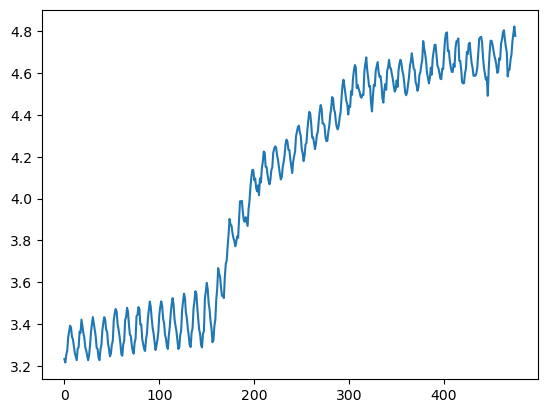

In [124]:
data_y['y'].plot()
plt.show()

In [125]:
data_y.head()

,ds,y
0,1990-01-31,3.232742
1,1990-02-28,3.216430
2,1990-03-31,3.253822
3,1990-04-30,3.273696
4,1990-05-31,3.337060


In [126]:
data_y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      476 non-null    datetime64[ns]
 1   y       476 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 7.6 KB


In [127]:
model = Prophet()
model.fit(data_y)

17:42:48 - cmdstanpy - INFO - Chain [1] start processing
17:42:48 - cmdstanpy - INFO - Chain [1] done processing


In [128]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [129]:
data_y.tail()

,ds,y
471,2029-04-30,4.690311
472,2029-05-31,4.753001
473,2029-06-30,4.790560
474,2029-07-31,4.823474
475,2029-08-31,4.778542


In [130]:
future = model.make_future_dataframe(periods=730)
future.tail()

,ds
1201,2031-08-27
1202,2031-08-28
1203,2031-08-29
1204,2031-08-30
1205,2031-08-31


In [131]:
prediction = model.predict(future)
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1990-01-31,3.304379,3.176646,3.234234,3.304379,3.304379,-0.098218,-0.098218,-0.098218,-0.098218,-0.098218,-0.098218,0.0,0.0,0.0,3.206160
1,1990-02-28,3.305244,3.181857,3.245587,3.305244,3.305244,-0.092333,-0.092333,-0.092333,-0.092333,-0.092333,-0.092333,0.0,0.0,0.0,3.212911
2,1990-03-31,3.306202,3.226557,3.286692,3.306202,3.306202,-0.049572,-0.049572,-0.049572,-0.049572,-0.049572,-0.049572,0.0,0.0,0.0,3.256630
3,1990-04-30,3.307129,3.240381,3.300415,3.307129,3.307129,-0.036585,-0.036585,-0.036585,-0.036585,-0.036585,-0.036585,0.0,0.0,0.0,3.270544
4,1990-05-31,3.308087,3.316829,3.376890,3.308087,3.308087,0.038552,0.038552,0.038552,0.038552,0.038552,0.038552,0.0,0.0,0.0,3.346638


In [132]:
prediction['yhat_original'] = np.exp(prediction['yhat'])
prediction['yhat_lower_original'] = np.exp(prediction['yhat_lower'])
prediction['yhat_upper_original'] = np.exp(prediction['yhat_upper'])

# View the updated DataFrame
prediction[['ds', 'yhat', 'yhat_original', 'yhat_lower_original', 'yhat_upper_original']].head()

,ds,yhat,yhat_original,yhat_lower_original,yhat_upper_original
0,1990-01-31,3.206160,24.684127,23.966226,25.386906
1,1990-02-28,3.212911,24.851322,24.091459,25.676789
2,1990-03-31,3.256630,25.961892,25.192759,26.754210
3,1990-04-30,3.270544,26.325647,25.543442,27.123880
4,1990-05-31,3.346638,28.407079,27.572787,29.279556


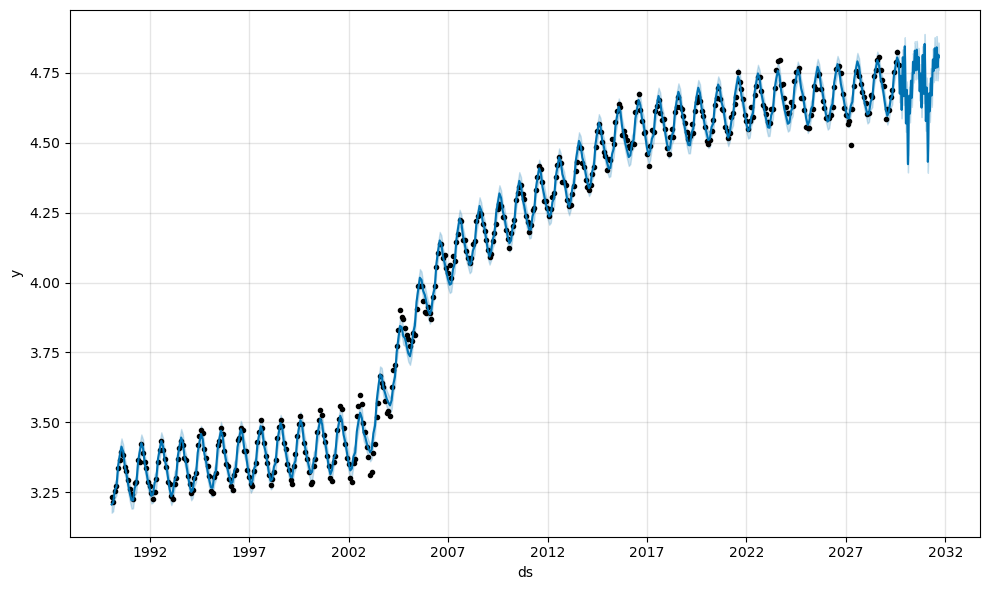

In [133]:
model.plot(prediction)
plt.savefig('prediction.png', bbox_inches='tight')
plt.show();

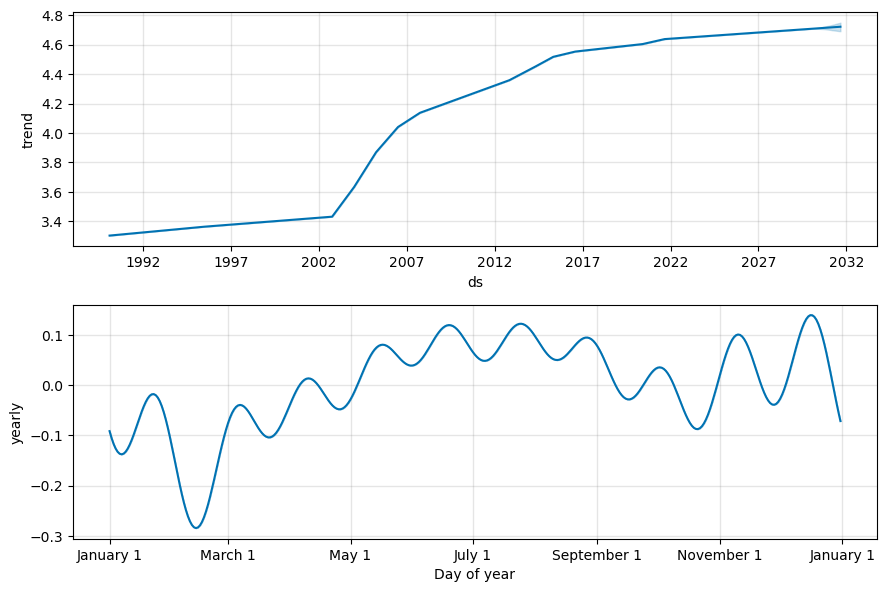

In [134]:
model.plot_components(prediction)
plt.savefig('trend_decomposition.png', bbox_inches='tight')
plt.show();

In [135]:
# initial = '730 days' : first 3 years of data used for training
# period = '180 days' : after every 180 days the model creates a new cutoff, retraining the model from start to that cutoff
# horizon = '365 days' : at each cutoff the model will pforecast the next 365 days and compare with actual values
data_cv = cross_validation(model, initial = '730 days', period = '180 days', horizon = '365 days')
data_cv.head()

  0%|          | 0/75 [00:00<?, ?it/s]

17:44:46 - cmdstanpy - INFO - Chain [1] start processing
17:45:00 - cmdstanpy - INFO - Chain [1] done processing
17:45:00 - cmdstanpy - INFO - Chain [1] start processing
17:45:15 - cmdstanpy - INFO - Chain [1] done processing
17:45:15 - cmdstanpy - INFO - Chain [1] start processing
17:45:16 - cmdstanpy - INFO - Chain [1] done processing
17:45:16 - cmdstanpy - INFO - Chain [1] start processing
17:45:16 - cmdstanpy - INFO - Chain [1] done processing
17:45:16 - cmdstanpy - INFO - Chain [1] start processing
17:45:17 - cmdstanpy - INFO - Chain [1] done processing
17:45:17 - cmdstanpy - INFO - Chain [1] start processing
17:45:17 - cmdstanpy - INFO - Chain [1] done processing
17:45:17 - cmdstanpy - INFO - Chain [1] start processing
17:45:18 - cmdstanpy - INFO - Chain [1] done processing
17:45:18 - cmdstanpy - INFO - Chain [1] start processing
17:45:18 - cmdstanpy - INFO - Chain [1] done processing
17:45:18 - cmdstanpy - INFO - Chain [1] start processing
17:45:18 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1992-03-31,3.209359,3.205217,3.213451,3.251151,1992-03-13
1,1992-04-30,3.241766,3.228624,3.254630,3.297542,1992-03-13
2,1992-05-31,3.257364,3.231848,3.282829,3.359835,1992-03-13
3,1992-06-30,3.357014,3.316727,3.398005,3.399847,1992-03-13
4,1992-07-31,3.274817,3.215116,3.336052,3.433290,1992-03-13


In [136]:
data_p = performance_metrics(data_cv)
data_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,0.001863,0.043159,0.031369,0.007743,0.006163,0.007741,0.393258
1,38 days,0.001961,0.044289,0.032572,0.008028,0.006192,0.008024,0.382022
2,39 days,0.001963,0.044311,0.032643,0.008060,0.006192,0.008055,0.370787
3,40 days,0.002001,0.044736,0.033197,0.008177,0.006548,0.008171,0.353933
4,41 days,0.001987,0.044580,0.033139,0.008161,0.006584,0.008156,0.348315


In [139]:
rmse_value_prophet = data_p['rmse'].mean()
rmse_value_prophet

0.05920214352675063

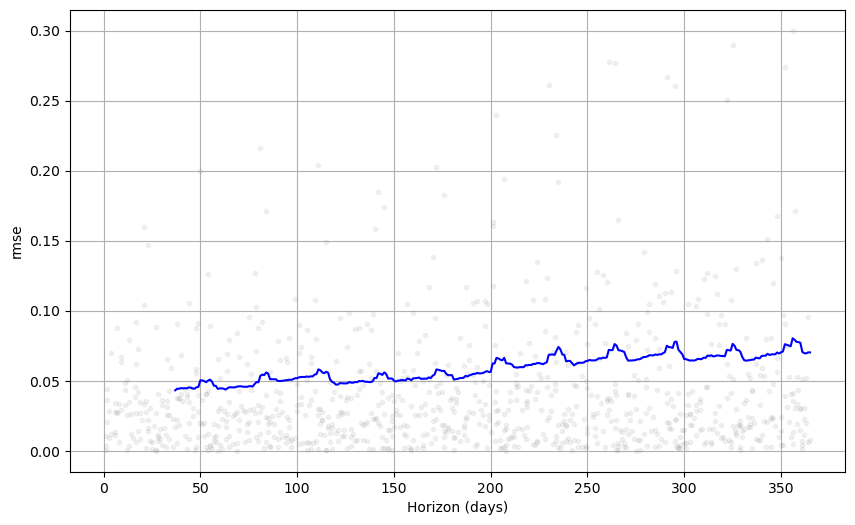

In [138]:
plot_cross_validation_metric(data_cv, metric='rmse')
plt.savefig('rmse_plot.png', bbox_inches='tight')
plt.show();

In [140]:
prophet_results = pd.DataFrame({'Model':['Prophet'], 'RMSE':[rmse_value_prophet]})
model_results = pd.concat([model_results, prophet_results], ignore_index=True)
model_results

,Model,RMSE
0,"SARIMA(1,0,1)(1,0,1,12)",1.010658
1,"ARIMA(4,0,4)]",1.798769
2,Prophet,0.059202
